---


Nama : Sintia Sari

NIM : 0110222135

Matkul : Machine Learning | Sesi Pagi

Rombel : TI08 - 2022



---


# 1. Import library

In [1]:
# Import library
import pandas as pd
import numpy as np

# Library Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Untuk 3D plot
# Pengaturan visualisasi
plt.rcParams['figure.figsize'] = (8, 6)

Kode diatas digunakan untuk menyiapkan analisis data dan machine learning. Pandas dan NumPy dipakai untuk mengolah data dan perhitungan numerik. Library Scikit-Learn digunakan untuk membagi data, menormalkan data, mengurangi dimensi dengan PCA, membuat model klasifikasi SVM, serta mengevaluasi hasil model. Matplotlib digunakan untuk membuat grafik, termasuk grafik 3D, dan pengaturan ukuran gambar dilakukan agar visualisasi lebih jelas

# 2. Load dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv("/content/drive/MyDrive/Machine Learning/Praktikum/Praktikum12/Data/data.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# 3. Eksplorasi awal dataset

In [4]:
# Informasi umum dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

Kode df.info() digunakan untuk menampilkan **informasi umum tentang dataset**. Hasilnya menunjukkan bahwa data memiliki **569 baris dan 33 kolom**, lengkap dengan nama kolom, jumlah data yang tidak kosong, dan tipe datanya. Terlihat bahwa sebagian besar kolom bertipe **angka (float)**, kolom **id** bertipe bilangan bulat, dan **diagnosis** bertipe teks. Kolom **Unnamed: 32** tidak memiliki data sama sekali, sehingga biasanya bisa dihapus karena tidak akan terpakai.


In [5]:
# Statistik deskriptif
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


Kode df.describe() digunakan untuk menampilkan **statistik deskriptif** dari data numerik. Hasilnya menunjukkan ringkasan seperti **jumlah data, nilai rata-rata, standar deviasi, nilai minimum, maksimum, dan kuartil**, yang membantu memahami sebaran dan karakteristik data secara singkat.


In [6]:
# Cek missing value
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


Kode df.isnull().sum() digunakan untuk **mengecek jumlah data kosong (missing value)** pada setiap kolom. Hasilnya menunjukkan bahwa **semua kolom memiliki nilai 0** (tidak ada data kosong), kecuali kolom **Unnamed: 32** yang memiliki **569 data kosong**, artinya seluruh isinya kosong dan kolom tersebut akan dihapus karena tidak memiliki informasi.


In [7]:
# Cek data duplikat
df.duplicated().sum()

np.int64(0)

Kode df.duplicated().sum() digunakan untuk **mengecek jumlah data yang duplikat** (baris yang sama persis). Hasil 0 menunjukkan bahwa **tidak ada data duplikat** dalam dataset, sehingga semua baris data bersifat unik.


In [8]:
# Cek distribusi target (Diagnosis: M = Malignant, B = Benign)
print("\n--- Jumlah Data per Label ---")
df['diagnosis'].value_counts()


--- Jumlah Data per Label ---


,count
diagnosis,
B,357
M,212


Kode df['diagnosis'].value_counts() digunakan untuk menghitung jumlah data pada setiap label target. Hasilnya menunjukkan bahwa terdapat 357 data Benign (B) dan 212 data Malignant (M), sehingga kelas Benign lebih banyak dibandingkan Malignant.

# 4. Data cleaning

In [9]:
 # Hapus kolom 'id' dan 'Unnamed: 32' karena tidak dipakai untuk prediksi
df_clean = df.drop(['id'], axis=1)
if 'Unnamed: 32' in df_clean.columns:
    df_clean = df_clean.drop(['Unnamed: 32'], axis=1)

Kode df.drop(['id'], axis=1) digunakan untuk **menghapus kolom id** karena tidak berguna untuk prediksi, lalu hasilnya disimpan ke **df_clean**. Selanjutnya, kode if Unnamed: 32 in df_clean.columns mengecek apakah kolom **Unnamed: 32** ada, dan jika ada maka kolom tersebut juga **dihapus**. Hasil akhirnya adalah **dataset yang lebih bersih**, hanya berisi kolom yang relevan untuk analisis dan pemodelan.


# 5. Pisahkan Fitur (X) dan Target (y)

In [10]:
# Fitur dan label
X = df_clean.drop('diagnosis', axis=1)
y = df_clean['diagnosis']

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (569, 30)
Shape y: (569,)


Kode df_clean.drop('diagnosis', axis=1) digunakan untuk memisahkan **fitur (X)**, yaitu semua kolom selain label. Kode df_clean['diagnosis'] digunakan untuk mengambil **label (y)** sebagai target prediksi. Hasil Shape X: (569, 30) menunjukkan terdapat **569 data dengan 30 fitur**, sedangkan Shape y: (569,) menunjukkan **569 label**, masing-masing satu untuk setiap data.


# 6. Encoding Target (M -> 1, B -> 0)

In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Label Kelas:", le.classes_)
print("Jumlah fitur:", X.shape[1])

Label Kelas: ['B' 'M']
Jumlah fitur: 30


Kode LabelEncoder() digunakan untuk **mengubah label teks menjadi angka**. Perintah le.fit_transform(y) mengonversi label **B dan M** menjadi nilai numerik agar bisa diproses oleh model machine learning. Hasil Label Kelas: ['B' 'M'] menunjukkan urutan kelas, sedangkan Jumlah fitur: 30 berarti data memiliki **30 fitur**.


# 7. Pembagian Data Latih dan Data Uji (Train-Test Split)

In [12]:
# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Shape X_train:", X_train.shape)
print("Shape X_test :", X_test.shape)

Shape X_train: (455, 30)
Shape X_test : (114, 30)


Kode train_test_split() digunakan untuk **membagi data** menjadi data latih dan data uji, dengan **80% untuk pelatihan** dan **20% untuk pengujian**. Parameter stratify=y memastikan proporsi label tetap seimbang, dan random_state=42 agar hasil pembagian selalu sama. Hasilnya, **X_train berisi 455 data dengan 30 fitur** dan **X_test berisi 114 data dengan 30 fitur**.


# 8. Standardisasi (Scaling)

In [13]:
scaler = StandardScaler()

# Fit pada training set, lalu transform ke training dan test set
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled[:5]

array([[ 5.18558727e-01,  8.91825791e-01,  4.24631702e-01,
         3.83925436e-01, -9.74743706e-01, -6.89771505e-01,
        -6.88586446e-01, -3.98175254e-01, -1.03915470e+00,
        -8.25056321e-01, -1.09317755e-01, -5.59755400e-02,
        -2.10096206e-01, -1.59132582e-02, -1.00518399e+00,
        -9.11941990e-01, -6.62815884e-01, -6.52561081e-01,
        -7.01889114e-01, -2.75393571e-01,  5.79797697e-01,
         1.31324246e+00,  4.66908134e-01,  4.45982711e-01,
        -5.96154777e-01, -6.34722227e-01, -6.10227299e-01,
        -2.35743918e-01,  5.45663235e-02,  2.18367276e-02],
       [-5.16364088e-01, -1.63971029e+00, -5.41348716e-01,
        -5.42961327e-01,  4.76219058e-01, -6.31833818e-01,
        -6.04281166e-01, -3.03074908e-01,  5.21543093e-01,
        -4.54522896e-01, -6.04377961e-01, -1.00104604e+00,
        -5.85429002e-01, -4.93453793e-01,  4.03212009e-01,
        -7.68173276e-01, -4.79187222e-01,  1.14508478e-01,
        -1.42950761e-01, -5.77397732e-01, -5.82458953e-

Kode StandardScaler() digunakan untuk **menormalkan data fitur** agar memiliki skala yang sama. fit_transform(X_train) menghitung skala dari data latih lalu mengubah nilainya, sedangkan transform(X_test) menerapkan skala yang sama ke data uji. Perintah X_train_scaled[:5] menampilkan **5 baris pertama data latih yang sudah dinormalisasi**, dengan nilai berbentuk angka kecil di sekitar nol.


# 9. Penerapan Model SVM tanpa PCA (Baseline Model)

In [14]:
# Inisialisasi model SVM
svm_no_pca = SVC(kernel='rbf', gamma='scale', random_state=42)

# Latih model menggunakan data asli yang sudah di-scaling (30 Fitur)
svm_no_pca.fit(X_train_scaled, y_train)

# Prediksi dan evaluasi
y_pred_no_pca = svm_no_pca.predict(X_test_scaled)

acc_no_pca = accuracy_score(y_test, y_pred_no_pca)
print(f"Akurasi SVM tanpa PCA: {acc_no_pca:.4f}")

# Kita definisikan nama kelas secara manual
target_names = ['Benign (B)', 'Malignant (M)']

print("\nClassification Report (tanpa PCA):")
print(classification_report(y_test, y_pred_no_pca, target_names=target_names))

Akurasi SVM tanpa PCA: 0.9737

Classification Report (tanpa PCA):
               precision    recall  f1-score   support

   Benign (B)       0.96      1.00      0.98        72
Malignant (M)       1.00      0.93      0.96        42

     accuracy                           0.97       114
    macro avg       0.98      0.96      0.97       114
 weighted avg       0.97      0.97      0.97       114



Kode SVC() digunakan untuk **membuat model SVM** dengan kernel RBF, lalu fit() melatih model menggunakan **data latih yang sudah dinormalisasi** tanpa PCA (30 fitur). Selanjutnya, predict() digunakan untuk **memprediksi data uji**, dan accuracy_score() menghitung **tingkat akurasi model**, yang menghasilkan nilai **97,37%**, artinya model sangat baik. classification_report() menampilkan detail performa model, di mana model **sangat akurat mengenali data Benign** dan **cukup tinggi dalam mengenali Malignant**, sehingga keseluruhan performa model dinilai sangat baik.


# 10. Penerapan PCA (Principal Component Analysis)

In [15]:
# Inisialisasi PCA dengan 2 komponen
pca = PCA(n_components=2)

# Terapkan PCA pada data yang sudah di-scale
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print('Shape X_train_pca:', X_train_pca.shape)
print('Shape X_test_pca:', X_test_pca.shape)

Shape X_train_pca: (455, 2)
Shape X_test_pca: (114, 2)


Kode PCA(n_components=2) digunakan untuk **mengurangi jumlah fitur menjadi 2 komponen utama**. fit_transform() menerapkan PCA pada data latih yang sudah dinormalisasi, sedangkan transform() menerapkannya pada data uji dengan pola yang sama. Hasilnya menunjukkan bahwa **data latih dan data uji kini hanya memiliki 2 fitur**, yaitu (455, 2) dan (114, 2), sehingga data lebih sederhana dan mudah divisualisasikan.


# 11. Analisis Explained Variance

In [16]:
explained_variance = pca.explained_variance_ratio_

print(f"Explained Variance per komponen: {explained_variance}")
print(f"Total informasi yang tersimpan: {np.sum(explained_variance) * 100:.2f}%")

Explained Variance per komponen: [0.44593522 0.18545255]
Total informasi yang tersimpan: 63.14%


Kode pca.explained_variance_ratio_ digunakan untuk **melihat seberapa besar informasi data yang dijelaskan oleh setiap komponen PCA**. Hasilnya menunjukkan bahwa **komponen pertama menjelaskan sekitar 44,6%** dan **komponen kedua sekitar 18,5%** informasi data. Perintah np.sum() menjumlahkan keduanya, sehingga terlihat bahwa **dua komponen PCA ini menyimpan sekitar 63,14% informasi total**, artinya sebagian besar pola data masih tetap terwakili meskipun jumlah fitur dikurangi.


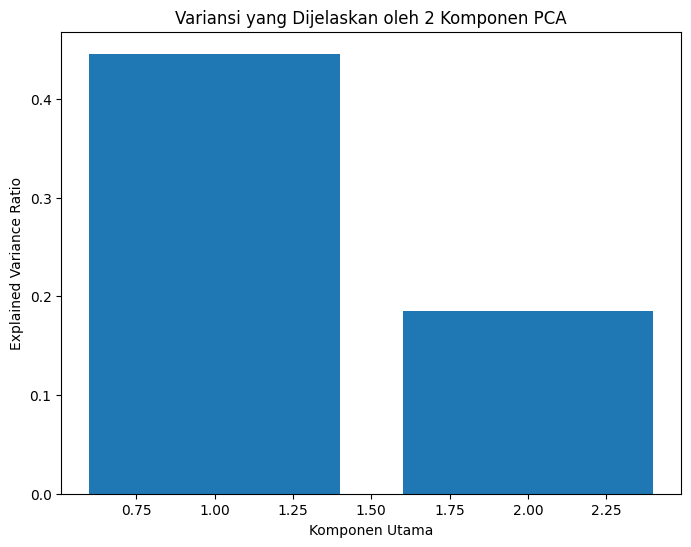

In [17]:
plt.bar([1, 2], explained_variance)
plt.xlabel('Komponen Utama')
plt.ylabel('Explained Variance Ratio')
plt.title('Variansi yang Dijelaskan oleh 2 Komponen PCA')
plt.show()

Kode plt.bar([1, 2], explained_variance) digunakan untuk **membuat grafik batang** yang menampilkan kontribusi masing-masing komponen PCA. plt.xlabel() dan plt.ylabel() memberi **nama sumbu X dan Y**, sedangkan plt.title() memberi **judul grafik**. plt.show() digunakan untuk **menampilkan grafik**, sehingga terlihat bahwa **komponen PCA pertama menjelaskan variansi lebih besar dibanding komponen kedua**.


# 12. Membangun Model SVM dengan PCA

In [18]:
svm_pca = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_pca.fit(X_train_pca, y_train)

# Prediksi data test yang sudah di-PCA (X_test_pca)
y_pred_pca = svm_pca.predict(X_test_pca)

# Evaluasi Akurasi
acc_pca = accuracy_score(y_test, y_pred_pca)

# Mengambil jumlah komponen secara otomatis dari variabel pca
n_components = pca.n_components_
print(f"Akurasi SVM dengan PCA ({n_components} komponen): {acc_pca:.4f}")

# Definisikan nama kelas secara manual untuk Breast Cancer
target_names = ['Benign (B)', 'Malignant (M)']

print("\nClassification Report (dengan PCA):")
print(classification_report(y_test, y_pred_pca, target_names=target_names))

Akurasi SVM dengan PCA (2 komponen): 0.9298

Classification Report (dengan PCA):
               precision    recall  f1-score   support

   Benign (B)       0.91      0.99      0.95        72
Malignant (M)       0.97      0.83      0.90        42

     accuracy                           0.93       114
    macro avg       0.94      0.91      0.92       114
 weighted avg       0.93      0.93      0.93       114



Kode SVC() digunakan untuk **membuat model SVM**, lalu fit() melatih model menggunakan **data latih yang sudah direduksi dengan PCA**. Selanjutnya, predict() digunakan untuk **memprediksi data uji hasil PCA**, dan`accuracy_score() menghitung **akurasi model**, yang menghasilkan **92,98%**, lebih rendah dibanding tanpa PCA. Variabel pca.n_components_ menampilkan jumlah komponen yang dipakai, yaitu **2 komponen**. classification_report() menunjukkan bahwa model masih cukup baik, tetapi **kemampuan mendeteksi Malignant sedikit menurun**, sehingga performanya lebih sederhana namun kurang akurat dibanding model tanpa PCA.


# 13. Visualisasi PCA dalam Ruang 3 Dimensi

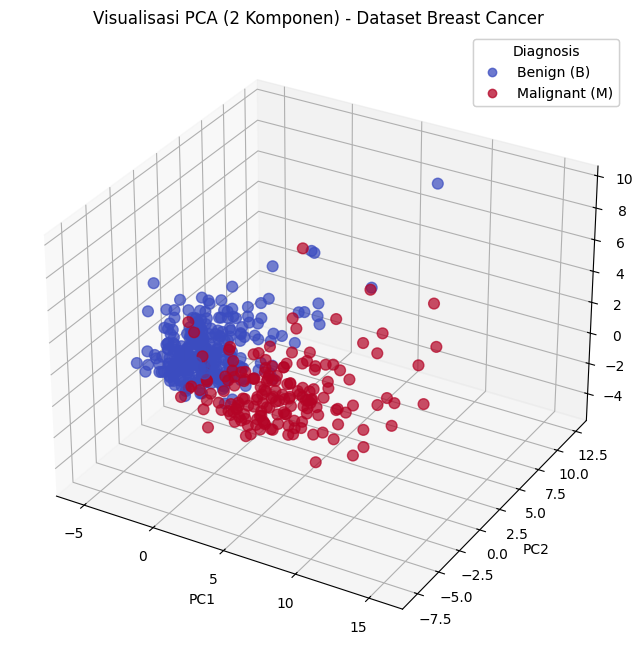

In [19]:
pca_3d = PCA(n_components=3)
X_train_pca_3d = pca_3d.fit_transform(X_train_scaled)

# --- Visualisasi 3D ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Encode y_train to numerical values for coloring
y_train_encoded_for_plot = le.transform(y_train)

scatter = ax.scatter(
    X_train_pca_3d[:, 0],
    X_train_pca_3d[:, 1],
    X_train_pca_3d[:, 2],
    c=y_train_encoded_for_plot,         # Pewarnaan berdasarkan target (0/1)
    cmap='coolwarm',   # Skema warna (Biru/Merah)
    s=60,              # Ukuran titik
    alpha=0.7          # Transparansi agar titik yang bertumpuk terlihat
)

ax.set_title('Visualisasi PCA (2 Komponen) - Dataset Breast Cancer')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')

# Tambahkan legend dengan nama kelas yang sesuai
# legend_elements()[0] mengambil simbol warna
# labels kita isi manual dengan nama kelas
legend1 = ax.legend(
    handles=scatter.legend_elements()[0],
    labels=['Benign (B)', 'Malignant (M)'],
    title="Diagnosis"
)
ax.add_artist(legend1)

plt.show()

Kode PCA(n_components=3) digunakan untuk **mengurangi data menjadi 3 komponen utama**, lalu fit_transform() menerapkannya pada data latih yang sudah dinormalisasi. Bagian plt.figure() dan add_subplot(..., projection='3d') digunakan untuk **membuat grafik 3 dimensi**. Label target y_train diubah menjadi angka agar bisa digunakan sebagai **warna titik** pada grafik. Fungsi ax.scatter() menampilkan **sebaran data dalam ruang 3D**, dengan warna berbeda untuk kelas Benign dan Malignant. Pengaturan judul, label sumbu, dan legenda membuat grafik **lebih mudah dipahami**, sehingga hasil akhirnya adalah **visualisasi PCA 3D** yang menunjukkan pemisahan antar kelas data.


# 14. Perbandingan Model SVM Tanpa PCA dan Dengan PCA


In [20]:
# Membandingkan hasil model tanpa dan dengan PCA
comparison = pd.DataFrame({
    'Model': ['SVM Tanpa PCA', 'SVM Dengan PCA (2 Komponen)'],
    'Jumlah Fitur': [X_train_scaled.shape[1], X_train_pca.shape[1]],
    'Akurasi': [acc_no_pca, acc_pca],
    'Variansi Total PCA': [None, explained_variance.sum()]
})

comparison

,Model,Jumlah Fitur,Akurasi,Variansi Total PCA
0,SVM Tanpa PCA,30,0.973684,NaN
1,SVM Dengan PCA (2 Komponen),2,0.929825,0.631388


Kode pd.DataFrame() digunakan untuk **membuat tabel perbandingan** antara model SVM tanpa PCA dan dengan PCA. Tabel ini menampilkan **nama model, jumlah fitur yang digunakan, nilai akurasi, dan total variansi PCA**. Hasilnya menunjukkan bahwa **SVM tanpa PCA memakai 30 fitur dan memiliki akurasi lebih tinggi**, sedangkan **SVM dengan PCA hanya memakai 2 fitur**, menyimpan sekitar **63% informasi data**, tetapi akurasinya sedikit lebih rendah.


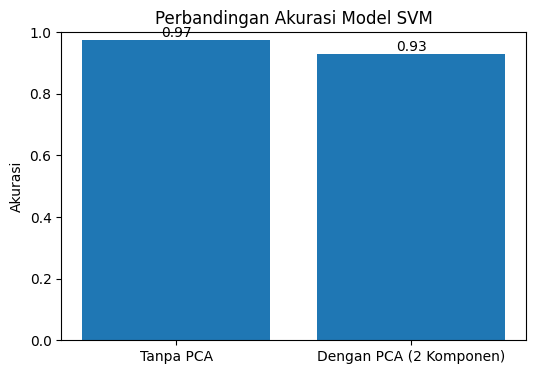

In [21]:
plt.figure(figsize=(6,4))
plt.bar(['Tanpa PCA', 'Dengan PCA (2 Komponen)'], [acc_no_pca, acc_pca])
plt.title('Perbandingan Akurasi Model SVM')
plt.ylabel('Akurasi')
plt.ylim(0, 1)
for i, v in enumerate([acc_no_pca, acc_pca]):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center')
plt.show()

Kode plt.figure() digunakan untuk **mengatur ukuran grafik**, lalu plt.bar() membuat **grafik batang** yang membandingkan akurasi SVM tanpa PCA dan dengan PCA. plt.title(), plt.ylabel(), dan plt.ylim() memberi **judul, label sumbu, dan batas nilai akurasi**. Perulangan plt.text() menampilkan **nilai akurasi di atas setiap batang**, dan plt.show() menampilkan grafik yang menunjukkan bahwa **akurasi model tanpa PCA lebih tinggi dibandingkan dengan PCA**.


Kesimpulan:

Praktikum ini bertujuan untuk memahami penerapan **Principal Component Analysis (PCA)** pada dataset medis **Breast Cancer** yang memiliki dimensi tinggi. PCA digunakan untuk mengurangi jumlah fitur dari 30 menjadi 2 komponen utama tanpa menghilangkan terlalu banyak informasi penting. Hasil eksperimen menunjukkan bahwa penggunaan PCA berhasil menyederhanakan data dan memudahkan visualisasi, namun menyebabkan penurunan akurasi model SVM dibandingkan tanpa PCA. Dengan demikian, PCA sangat bermanfaat untuk reduksi dimensi dan pemahaman pola data, tetapi perlu dipertimbangkan trade-off antara penyederhanaan data dan performa model dalam aplikasi medis.
